# BTXRD Portion 1 — Dataset Engineering, Quality Control, Journal Visuals & Splits

**Project:** BTX-TrustNet for primary bone tumor radiograph analysis  
**Portion 1 goal:** convert the raw BTXRD folder into clean, high-quality, model-ready files.

This notebook does **not** train the model. It prepares the dataset so Portion 2 can start cleanly.

## What this notebook creates

| Output | Purpose |
|---|---|
| `btxrd_master_all_audited.csv` | full audited metadata table |
| `btxrd_master_gold_multitask.csv` | best data for the final multi-task model |
| `btxrd_master_classification_all_valid.csv` | best valid classification-only data |
| `masks_png/` | binary tumor masks generated from LabelMe JSON |
| `splits/` | train/val/test CSVs for internal and center-held-out experiments |
| `coco/` | COCO-style detection/segmentation JSON files |
| `yolo_bbox_gold/` | YOLO-ready image links and bbox label files |
| `figures/` | 300 DPI journal-style dataset figures |
| `BTXRD_Portion1_Audit_Report.md` | automatic dataset audit report |

## Gold data rule

For the final BTX-TrustNet pipeline, this notebook marks a sample as **gold-multitask** only when it has:

1. readable X-ray image,
2. valid three-class label: `normal`, `benign`, or `malignant`,
3. sufficient image quality checks,
4. no exact duplicate file retained twice,
5. for tumor images: valid segmentation mask and valid bounding box,
6. for normal images: included as clean negative samples.

This gives the strongest data foundation for high accuracy, segmentation-guided learning, XAI alignment, and uncertainty-aware diagnosis.

In [1]:
# ============================================================
# 0. Imports, reproducibility, and journal-style configuration
# ============================================================
import os
import re
import json
import math
import shutil
import hashlib
import random
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageOps, ImageDraw, UnidentifiedImageError
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

try:
    import cv2
except Exception:
    cv2 = None

try:
    from sklearn.model_selection import train_test_split
except Exception as e:
    raise RuntimeError("scikit-learn is required for split generation. On Kaggle it is normally preinstalled.") from e

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

warnings.filterwarnings("ignore")
Image.MAX_IMAGE_PIXELS = None

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)

# Output folder. Kaggle writes to /kaggle/working.
OUT_DIR = Path("/kaggle/working/BTXRD_Portion1") if Path("/kaggle/working").exists() else Path.cwd() / "BTXRD_Portion1"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
MASK_DIR = OUT_DIR / "masks_png"
SPLIT_DIR = OUT_DIR / "splits"
COCO_DIR = OUT_DIR / "coco"
YOLO_DIR = OUT_DIR / "yolo_bbox_gold"
REPORT_DIR = OUT_DIR / "reports"

for d in [OUT_DIR, TABLE_DIR, FIG_DIR, MASK_DIR, SPLIT_DIR, COCO_DIR, YOLO_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Quality thresholds for gold data.
MIN_SHORT_SIDE = 224
MIN_GRAY_STD = 5.0
MAX_ASPECT_SYMMETRIC = 6.0
MIN_MASK_PIXELS = 20
MIN_BBOX_SIDE = 3

# Classification label order used everywhere.
LABEL_ORDER = ["normal", "benign", "malignant"]
LABEL_TO_ID = {"normal": 0, "benign": 1, "malignant": 2}

# Journal-style plot settings.
CLASS_COLORS = {
    "normal": "#4C78A8",
    "benign": "#F58518",
    "malignant": "#E45756",
    "tumor": "#A23B72",
    "unknown": "#9E9E9E",
}

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.6,
})

print(f"Output directory: {OUT_DIR}")
print(f"OpenCV available: {cv2 is not None}")

Output directory: /kaggle/working/BTXRD_Portion1
OpenCV available: True


## 1. Locate the BTXRD dataset automatically

Your Kaggle screenshot shows this structure:

```text
BTXRD dataset/
└── BTXRD/
    ├── Annotations/
    ├── images/
    ├── dataset.xlsx
    └── ~$dataset(total).xlsx
```

The code below searches `/kaggle/input`, `/mnt/data`, and the current directory for a folder containing `images`, `Annotations`, and a metadata file. Temporary Excel files beginning with `~$` are ignored.

In [2]:
# ============================================================
# 1. Dataset discovery
# ============================================================
SUPPORTED_IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
SUPPORTED_TABLE_EXTS = {".csv", ".xlsx", ".xls"}


def find_child_dir_case_insensitive(parent: Path, name: str):
    for p in parent.iterdir():
        if p.is_dir() and p.name.lower() == name.lower():
            return p
    return None


def is_metadata_file(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in SUPPORTED_TABLE_EXTS and not p.name.startswith("~$")


def looks_like_btxrd_root(root: Path) -> bool:
    if not root.is_dir():
        return False
    child_names = {p.name.lower() for p in root.iterdir() if p.is_dir()}
    has_images = "images" in child_names
    has_annotations = "annotations" in child_names
    has_metadata = any(is_metadata_file(p) for p in root.iterdir())
    return has_images and has_annotations and has_metadata


def find_btxrd_root(search_roots=None):
    if search_roots is None:
        search_roots = [Path("/kaggle/input"), Path("/mnt/data"), Path.cwd()]
    candidates = []
    for base in search_roots:
        if not base.exists():
            continue
        for root, dirs, files in os.walk(base):
            root_p = Path(root)
            # Avoid scanning our output folder again.
            if OUT_DIR in root_p.parents or root_p == OUT_DIR:
                continue
            dir_lower = {d.lower() for d in dirs}
            has_images = "images" in dir_lower
            has_annotations = "annotations" in dir_lower
            has_metadata = any((Path(f).suffix.lower() in SUPPORTED_TABLE_EXTS and not f.startswith("~$")) for f in files)
            if has_images and has_annotations and has_metadata:
                candidates.append(root_p)
    candidates = sorted(set(candidates), key=lambda p: (len(str(p)), str(p)))
    if not candidates:
        raise FileNotFoundError(
            "Could not find BTXRD root. Check that the dataset is attached and contains images/, Annotations/, and dataset.xlsx/csv."
        )
    return candidates[0], candidates


BTXRD_ROOT, ROOT_CANDIDATES = find_btxrd_root()
IMAGES_DIR = find_child_dir_case_insensitive(BTXRD_ROOT, "images")
ANNOTATIONS_DIR = find_child_dir_case_insensitive(BTXRD_ROOT, "Annotations")

metadata_files = [p for p in BTXRD_ROOT.iterdir() if is_metadata_file(p)]
# Prefer dataset.csv, then dataset.xlsx, then any non-temp metadata file.
metadata_files = sorted(metadata_files, key=lambda p: (0 if p.name.lower() == "dataset.csv" else 1 if p.name.lower() == "dataset.xlsx" else 2, p.name))
DATA_FILE = metadata_files[0]

print("BTXRD root candidates:")
for c in ROOT_CANDIDATES:
    print("  -", c)
print("\nSelected BTXRD root:", BTXRD_ROOT)
print("Images dir:", IMAGES_DIR)
print("Annotations dir:", ANNOTATIONS_DIR)
print("Metadata file:", DATA_FILE)

BTXRD root candidates:
  - /kaggle/input/datasets/koushikrudra/btxrd-dataset/BTXRD

Selected BTXRD root: /kaggle/input/datasets/koushikrudra/btxrd-dataset/BTXRD
Images dir: /kaggle/input/datasets/koushikrudra/btxrd-dataset/BTXRD/images
Annotations dir: /kaggle/input/datasets/koushikrudra/btxrd-dataset/BTXRD/Annotations
Metadata file: /kaggle/input/datasets/koushikrudra/btxrd-dataset/BTXRD/dataset.xlsx


## 2. Load metadata and build image index

The notebook supports both `.xlsx` and `.csv`. It also performs robust image-file matching, so it works whether the metadata uses `IMG000001.jpeg`, `IMG000001`, a full path, or another similar image identifier.

In [3]:
# ============================================================
# 2. Load metadata and image index
# ============================================================

def load_metadata(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
    elif path.suffix.lower() in {".xlsx", ".xls"}:
        df = pd.read_excel(path, engine="openpyxl")
    else:
        raise ValueError(f"Unsupported metadata file: {path}")
    # Drop empty rows and columns.
    df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")
    df.columns = [str(c).strip() for c in df.columns]
    return df


def norm_col(s) -> str:
    s = str(s).strip().lower()
    s = re.sub(r"[\u2010-\u2015\-]+", "_", s)
    s = re.sub(r"[\s/()\[\]{}:+#*.]+", "_", s)
    s = re.sub(r"[^a-z0-9_]+", "", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s


def norm_lookup(s) -> str:
    s = Path(str(s)).name.strip().lower()
    # Remove extension if present.
    if "." in s:
        s = s.rsplit(".", 1)[0]
    return re.sub(r"[^a-z0-9]+", "", s)


raw_df = load_metadata(DATA_FILE)
dfn = raw_df.copy()
dfn.columns = [norm_col(c) for c in raw_df.columns]

image_paths = sorted([p for p in IMAGES_DIR.rglob("*") if p.suffix.lower() in SUPPORTED_IMAGE_EXTS])
image_index = defaultdict(list)
for p in image_paths:
    image_index[norm_lookup(p.name)].append(p)
    image_index[norm_lookup(p.stem)].append(p)


def resolve_image(value):
    if pd.isna(value):
        return None
    key = norm_lookup(value)
    if key in image_index and len(image_index[key]) > 0:
        return image_index[key][0]
    # Some sheets may store IMG plus numeric ID. Try zero-padding numeric values.
    s = str(value).strip()
    digits = re.sub(r"\D", "", s)
    if digits:
        for pad in [6, 5, 4, 3]:
            key2 = norm_lookup(f"IMG{int(digits):0{pad}d}")
            if key2 in image_index and len(image_index[key2]) > 0:
                return image_index[key2][0]
    return None


def find_image_column(df_raw: pd.DataFrame, sample_size: int = 500):
    scores = []
    for col in df_raw.columns:
        vals = df_raw[col].dropna().astype(str).head(sample_size)
        if len(vals) == 0:
            continue
        matches = sum(resolve_image(v) is not None for v in vals)
        score = matches / len(vals)
        scores.append((score, matches, col))
    scores = sorted(scores, reverse=True, key=lambda x: (x[0], x[1]))
    best = scores[0] if scores else (0, 0, None)
    return best, scores


best_image_col, image_col_scores = find_image_column(raw_df)
IMAGE_COL = best_image_col[2] if best_image_col[0] >= 0.20 else None

print(f"Metadata rows: {len(raw_df):,}")
print(f"Images found: {len(image_paths):,}")
print(f"Best image column: {IMAGE_COL} | match score={best_image_col[0]:.3f} | matches={best_image_col[1]}")
print("Top image-column candidates:")
for score, matches, col in image_col_scores[:5]:
    print(f"  {col}: score={score:.3f}, matches={matches}")

raw_df.head()

Metadata rows: 3,746
Images found: 3,746
Best image column: image_id | match score=1.000 | matches=500
Top image-column candidates:
  image_id: score=1.000, matches=500
  center: score=1.000, matches=500
  age: score=1.000, matches=500
  tumor: score=1.000, matches=500
  lower limb: score=0.686, matches=343


,image_id,center,age,gender,hand,ulna,radius,humerus,foot,tibia,...,synovial osteochondroma,other bt,osteosarcoma,other mt,upper limb,lower limb,pelvis,frontal,lateral,oblique
0,IMG000001.jpeg,1,48,F,0,0,0,0,0,0,...,0,0,0,1,0,0,1,1,0,0
1,IMG000002.jpeg,1,12,M,0,0,0,0,0,1,...,0,0,1,0,0,1,0,1,0,0
2,IMG000003.jpeg,1,12,M,0,0,0,0,0,1,...,0,0,1,0,0,1,0,0,1,0
3,IMG000004.jpeg,1,52,M,0,0,0,0,1,0,...,0,0,1,0,0,1,0,1,0,0
4,IMG000005.jpeg,1,52,M,0,0,0,0,1,0,...,0,0,1,0,0,1,0,0,0,1


## 3. Standardize labels and clinical metadata

This cell creates a clean master table with canonical columns:

```text
image_id, image_path, label_3class, label_binary, age, gender, center,
body_region, anatomical_site, view_angle, tumor_subtype
```

The code supports both categorical metadata and one-hot metadata columns, because BTXRD metadata may represent labels as binary markers such as `normal`, `benign`, `malignant`, `center1`, `frontal`, `lateral`, and anatomical-site columns.

In [4]:
# ============================================================
# 3. Metadata standardization
# ============================================================

def truthy(x) -> bool:
    if pd.isna(x):
        return False
    if isinstance(x, (int, float, np.integer, np.floating)):
        try:
            return float(x) == 1.0
        except Exception:
            return False
    s = str(x).strip().lower()
    if s in {"1", "1.0", "true", "t", "yes", "y", "positive", "present", "pos"}:
        return True
    return False


def is_binary_series(s: pd.Series) -> bool:
    vals = s.dropna().unique()
    if len(vals) == 0:
        return False
    vals_norm = {str(v).strip().lower() for v in vals}
    allowed = {"0", "0.0", "1", "1.0", "true", "false", "yes", "no", "y", "n"}
    if vals_norm.issubset(allowed):
        return True
    try:
        vals_float = set(pd.to_numeric(pd.Series(vals), errors="coerce").dropna().astype(float).unique())
        return vals_float.issubset({0.0, 1.0})
    except Exception:
        return False


def existing_cols(alias_list):
    aliases = {norm_col(a) for a in alias_list}
    return [c for c in dfn.columns if c in aliases]


def row_has_any(row, cols):
    return any(truthy(row.get(c, np.nan)) for c in cols)


def normalize_label_value(v):
    if pd.isna(v):
        return None
    s = norm_col(v)
    if not s:
        return None
    if "normal" in s or "healthy" in s or s in {"negative", "non_tumor", "nontumor", "non_tumour", "nontumour"}:
        return "normal"
    if "malignant" in s or s in {"m_tumor", "mtumor", "m_tumour", "mtumour", "malignancy", "m"}:
        return "malignant"
    if "benign" in s or s in {"b_tumor", "btumor", "b_tumour", "btumour", "b"}:
        return "benign"
    return None


def find_direct_label_col():
    preferred_names = {norm_col(x) for x in ["label", "class", "category", "diagnosis", "global_label", "label_3class", "target"]}
    candidates = []
    for c in dfn.columns:
        if c not in preferred_names and not any(k in c for k in ["label", "class", "category", "diagnosis", "target"]):
            continue
        if is_binary_series(dfn[c]):
            continue
        vals = dfn[c].dropna().astype(str)
        if len(vals) == 0:
            continue
        hits = vals.map(normalize_label_value).notna().sum()
        score = hits / len(vals)
        if score >= 0.25:
            candidates.append((score, hits, c))
    candidates = sorted(candidates, reverse=True)
    return candidates[0][2] if candidates else None


LABEL_VALUE_COL = find_direct_label_col()
normal_cols = existing_cols(["normal", "normal_bone", "healthy", "n_bone", "non_tumor", "nontumor"])
benign_cols = existing_cols(["benign", "b_tumor", "btumor", "b_tumour", "btumour", "benign_tumor", "benign_bone_tumor", "b_tumor_"])
malignant_cols = existing_cols(["malignant", "m_tumor", "mtumor", "m_tumour", "mtumour", "malignant_tumor", "malignant_bone_tumor", "m_tumor_"])

def infer_label(row):
    if LABEL_VALUE_COL is not None:
        lab = normalize_label_value(row.get(LABEL_VALUE_COL, np.nan))
        if lab is not None:
            return lab
    # Prioritize malignant and benign if multiple fields are accidentally true.
    if row_has_any(row, malignant_cols):
        return "malignant"
    if row_has_any(row, benign_cols):
        return "benign"
    if row_has_any(row, normal_cols):
        return "normal"
    return np.nan


def first_direct_col(names, exclude_binary=True):
    names_n = [norm_col(n) for n in names]
    for n in names_n:
        if n in dfn.columns and (not exclude_binary or not is_binary_series(dfn[n])):
            return n
    # Conservative partial match.
    for c in dfn.columns:
        if any(n == c or c.endswith("_" + n) or c.startswith(n + "_") for n in names_n):
            if not exclude_binary or not is_binary_series(dfn[c]):
                return c
    return None


def normalize_gender(v):
    if pd.isna(v):
        return np.nan
    s = norm_col(v)
    if s in {"m", "male", "man"}:
        return "M"
    if s in {"f", "female", "woman"}:
        return "F"
    return str(v).strip() if str(v).strip() else np.nan


def normalize_center(v):
    if pd.isna(v):
        return np.nan
    s = norm_col(v)
    if s in {"1", "center1", "center_1", "c1", "source1", "source_1"}:
        return "Center 1"
    if s in {"2", "center2", "center_2", "c2", "source2", "source_2"}:
        return "Center 2"
    if s in {"3", "center3", "center_3", "c3", "source3", "source_3"}:
        return "Center 3"
    if "center" in s and "1" in s:
        return "Center 1"
    if "center" in s and "2" in s:
        return "Center 2"
    if "center" in s and "3" in s:
        return "Center 3"
    return str(v).strip() if str(v).strip() else np.nan


def infer_onehot_category(row, alias_dict):
    hits = []
    for canonical, aliases in alias_dict.items():
        cols = existing_cols(aliases)
        if row_has_any(row, cols):
            hits.append(canonical)
    if len(hits) == 1:
        return hits[0]
    if len(hits) > 1:
        return ";".join(hits)
    return np.nan


def normalize_free_text(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip()
    return s if s else np.nan


CENTER_ALIASES = {
    "Center 1": ["center1", "center_1", "c1", "source1", "source_1"],
    "Center 2": ["center2", "center_2", "c2", "source2", "source_2"],
    "Center 3": ["center3", "center_3", "c3", "source3", "source_3"],
}
REGION_ALIASES = {
    "upper_limb": ["upper_limb", "upperlimb", "upper_extremity", "upper_extremities"],
    "lower_limb": ["lower_limb", "lowerlimb", "lower_extremity", "lower_extremities"],
    "pelvis": ["pelvis", "pelvic", "hip_region"],
}
VIEW_ALIASES = {
    "frontal": ["frontal", "front", "ap", "pa", "anteroposterior"],
    "lateral": ["lateral", "lat", "side"],
    "oblique": ["oblique", "obl"],
}
SITE_ALIASES = {
    "hand": ["hand", "hands"],
    "ulna": ["ulna"],
    "radius": ["radius"],
    "humerus": ["humerus"],
    "wrist_joint": ["wrist", "wrist_joint", "wrist_joints"],
    "elbow_joint": ["elbow", "elbow_joint", "elbow_joints"],
    "shoulder_joint": ["shoulder", "shoulder_joint", "shoulder_joints"],
    "foot": ["foot", "feet"],
    "tibia": ["tibia"],
    "fibula": ["fibula"],
    "femur": ["femur"],
    "ankle_joint": ["ankle", "ankle_joint", "ankle_joints"],
    "knee_joint": ["knee", "knee_joint", "knee_joints"],
    "hip": ["hip", "hips"],
    "hip_joint": ["hip_joint", "hip_joints"],
    "pelvis": ["pelvis", "pelvic"],
}
SUBTYPE_ALIASES = {
    "osteochondroma": ["osteochondroma"],
    "multiple_osteochondromatosis": ["multiple_osteochondromatosis", "multiple_osteochondroma", "multiple_osteochondromas"],
    "simple_bone_cyst": ["simple_bone_cyst", "bone_cyst", "unicameral_bone_cyst"],
    "fibrous_dysplasia": ["fibrous_dysplasia"],
    "chondroblastoma": ["chondroblastoma"],
    "giant_cell_tumor": ["giant_cell_tumor", "giant_cell_tumor_of_bone", "gct"],
    "osteoblastoma": ["osteoblastoma"],
    "osteoma": ["osteoma"],
    "hemangioma": ["hemangioma", "haemangioma"],
    "osteosarcoma": ["osteosarcoma"],
    "chondrosarcoma": ["chondrosarcoma"],
    "ewing_sarcoma": ["ewing_sarcoma", "ewings_sarcoma", "ewing"],
    "fibrosarcoma": ["fibrosarcoma"],
    "other_bt": ["other_bt", "other_benign", "other_benign_tumor"],
    "other_mt": ["other_mt", "other_malignant", "other_malignant_tumor"],
}

# Build canonical master table.
master = pd.DataFrame(index=raw_df.index)
master["source_row"] = np.arange(len(raw_df))

if IMAGE_COL is not None:
    master["image_file_raw"] = raw_df[IMAGE_COL].astype(str)
    master["image_path"] = raw_df[IMAGE_COL].map(resolve_image)
else:
    # Last-resort fallback: if row count equals image count, use sorted image order.
    if len(raw_df) == len(image_paths):
        master["image_file_raw"] = [p.name for p in image_paths]
        master["image_path"] = image_paths
        print("WARNING: no image column confidently detected. Using sorted image order because row count equals image count.")
    else:
        master["image_file_raw"] = np.nan
        master["image_path"] = None
        print("WARNING: no image column detected and row count does not equal image count.")

master["image_path"] = master["image_path"].map(lambda p: str(p) if p is not None else np.nan)
master["image_file"] = master["image_path"].map(lambda p: Path(p).name if isinstance(p, str) and p != "nan" else np.nan)
master["image_id"] = master["image_path"].map(lambda p: Path(p).stem if isinstance(p, str) and p != "nan" else np.nan)

# Labels.
master["label_3class"] = dfn.apply(infer_label, axis=1)
master["label_binary"] = master["label_3class"].map(lambda x: "normal" if x == "normal" else "tumor" if x in {"benign", "malignant"} else np.nan)
master["label_id"] = master["label_3class"].map(LABEL_TO_ID)

# Age.
age_col = first_direct_col(["age", "age_y", "age_year", "age_years", "age_yr"], exclude_binary=True)
master["age"] = pd.to_numeric(dfn[age_col], errors="coerce") if age_col is not None else np.nan

# Gender.
gender_col = first_direct_col(["gender", "sex"], exclude_binary=True)
if gender_col is not None:
    master["gender"] = dfn[gender_col].map(normalize_gender)
else:
    male_cols = existing_cols(["male", "m_gender", "gender_m"])
    female_cols = existing_cols(["female", "f_gender", "gender_f"])
    def infer_gender(row):
        if row_has_any(row, male_cols):
            return "M"
        if row_has_any(row, female_cols):
            return "F"
        return np.nan
    master["gender"] = dfn.apply(infer_gender, axis=1)

# Center.
center_col = first_direct_col(["center", "source", "data_source", "institution"], exclude_binary=True)
if center_col is not None:
    master["center"] = dfn[center_col].map(normalize_center)
else:
    master["center"] = dfn.apply(lambda row: infer_onehot_category(row, CENTER_ALIASES), axis=1)

# Body region.
region_col = first_direct_col(["body_region", "region", "limb_region"], exclude_binary=True)
if region_col is not None:
    master["body_region"] = dfn[region_col].map(lambda x: norm_col(x) if pd.notna(x) else np.nan)
else:
    master["body_region"] = dfn.apply(lambda row: infer_onehot_category(row, REGION_ALIASES), axis=1)

# View angle.
view_col = first_direct_col(["view", "view_angle", "shooting_angle", "projection", "position"], exclude_binary=True)
if view_col is not None:
    master["view_angle"] = dfn[view_col].map(lambda x: norm_col(x) if pd.notna(x) else np.nan)
else:
    master["view_angle"] = dfn.apply(lambda row: infer_onehot_category(row, VIEW_ALIASES), axis=1)

# Anatomical site.
site_col = first_direct_col(["anatomical_site", "site", "location", "bone", "body_part", "part_of_body_imaged", "organ"], exclude_binary=True)
if site_col is not None:
    master["anatomical_site"] = dfn[site_col].map(lambda x: norm_col(x) if pd.notna(x) else np.nan)
else:
    master["anatomical_site"] = dfn.apply(lambda row: infer_onehot_category(row, SITE_ALIASES), axis=1)

# Tumor subtype.
subtype_col = first_direct_col(["subtype", "tumor_subtype", "histology", "pathology", "diagnosis_subtype"], exclude_binary=True)
if subtype_col is not None:
    master["tumor_subtype"] = dfn[subtype_col].map(lambda x: norm_col(x) if pd.notna(x) else np.nan)
else:
    master["tumor_subtype"] = dfn.apply(lambda row: infer_onehot_category(row, SUBTYPE_ALIASES), axis=1)
master.loc[master["label_3class"] == "normal", "tumor_subtype"] = "normal"

# Metadata completeness score.
metadata_cols = ["age", "gender", "center", "body_region", "anatomical_site", "view_angle", "tumor_subtype"]
master["metadata_nonmissing_count"] = master[metadata_cols].notna().sum(axis=1)
master["metadata_completeness"] = master["metadata_nonmissing_count"] / len(metadata_cols)

print("Detected metadata columns")
print("- image column:", IMAGE_COL)
print("- direct label column:", LABEL_VALUE_COL)
print("- one-hot normal cols:", normal_cols)
print("- one-hot benign cols:", benign_cols)
print("- one-hot malignant cols:", malignant_cols)
print("- age column:", age_col)
print("- gender column:", gender_col)
print("- center column:", center_col)
print("- region column:", region_col)
print("- view column:", view_col)
print("- site column:", site_col)
print("- subtype column:", subtype_col)

print("\nClass distribution after standardization:")
display(master["label_3class"].value_counts(dropna=False).to_frame("count"))

print("\nCenter distribution after standardization:")
display(master["center"].value_counts(dropna=False).to_frame("count"))

master.head()

Detected metadata columns
- image column: image_id
- direct label column: None
- one-hot normal cols: []
- one-hot benign cols: ['benign']
- one-hot malignant cols: ['malignant']
- age column: age
- gender column: None
- center column: center
- region column: None
- view column: None
- site column: None
- subtype column: None

Class distribution after standardization:


,count
label_3class,
NaN,1879
benign,1525
malignant,342



Center distribution after standardization:


,count
center,
Center 1,2938
Center 2,549
Center 3,259


,source_row,image_file_raw,image_path,image_file,image_id,label_3class,label_binary,label_id,age,gender,center,body_region,view_angle,anatomical_site,tumor_subtype,metadata_nonmissing_count,metadata_completeness
0,0,IMG000001.jpeg,/kaggle/input/datasets/koushikrudra/btxrd-data...,IMG000001.jpeg,IMG000001,malignant,tumor,2.0,48,NaN,Center 1,pelvis,frontal,pelvis,other_mt,6,0.857143
1,1,IMG000002.jpeg,/kaggle/input/datasets/koushikrudra/btxrd-data...,IMG000002.jpeg,IMG000002,malignant,tumor,2.0,12,NaN,Center 1,lower_limb,frontal,tibia,osteosarcoma,6,0.857143
2,2,IMG000003.jpeg,/kaggle/input/datasets/koushikrudra/btxrd-data...,IMG000003.jpeg,IMG000003,malignant,tumor,2.0,12,NaN,Center 1,lower_limb,lateral,tibia,osteosarcoma,6,0.857143
3,3,IMG000004.jpeg,/kaggle/input/datasets/koushikrudra/btxrd-data...,IMG000004.jpeg,IMG000004,malignant,tumor,2.0,52,NaN,Center 1,lower_limb,frontal,foot,osteosarcoma,6,0.857143
4,4,IMG000005.jpeg,/kaggle/input/datasets/koushikrudra/btxrd-data...,IMG000005.jpeg,IMG000005,malignant,tumor,2.0,52,NaN,Center 1,lower_limb,oblique,foot,osteosarcoma,6,0.857143


## 4. Image-level quality audit

This cell checks every radiograph for:

- readable image file,
- width and height,
- short-side resolution,
- aspect ratio outliers,
- blank / near-blank image signal,
- exact duplicate file hash.

The notebook keeps **one copy** of exact duplicate files in the gold dataset.

In [5]:
# ============================================================
# 4. Image quality audit
# ============================================================

def md5_file(path, chunk_size=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()


def average_hash_from_array(arr, hash_size=8):
    # arr must be grayscale uint8-like.
    img = Image.fromarray(arr).resize((hash_size, hash_size), Image.Resampling.BILINEAR)
    a = np.asarray(img, dtype=np.float32)
    bits = (a > a.mean()).astype(np.uint8).flatten()
    return "".join(map(str, bits.tolist()))


def audit_image(path_value):
    rec = {
        "image_readable": False,
        "width": np.nan,
        "height": np.nan,
        "short_side": np.nan,
        "long_side": np.nan,
        "aspect_ratio": np.nan,
        "aspect_ratio_symmetric": np.nan,
        "image_mode": np.nan,
        "gray_mean": np.nan,
        "gray_std": np.nan,
        "gray_min": np.nan,
        "gray_max": np.nan,
        "file_size_kb": np.nan,
        "file_md5": np.nan,
        "average_hash": np.nan,
        "image_error": np.nan,
    }
    try:
        if pd.isna(path_value):
            rec["image_error"] = "missing_path"
            return rec
        p = Path(path_value)
        if not p.exists():
            rec["image_error"] = "path_not_found"
            return rec
        with Image.open(p) as im:
            w, h = im.size
            gray = im.convert("L")
            small = gray.resize((128, 128), Image.Resampling.BILINEAR)
            arr = np.asarray(small, dtype=np.float32)
            rec.update({
                "image_readable": True,
                "width": int(w),
                "height": int(h),
                "short_side": int(min(w, h)),
                "long_side": int(max(w, h)),
                "aspect_ratio": float(w / h) if h else np.nan,
                "aspect_ratio_symmetric": float(max(w / h, h / w)) if w and h else np.nan,
                "image_mode": im.mode,
                "gray_mean": float(arr.mean()),
                "gray_std": float(arr.std()),
                "gray_min": float(arr.min()),
                "gray_max": float(arr.max()),
                "file_size_kb": float(p.stat().st_size / 1024.0),
                "file_md5": md5_file(p),
                "average_hash": average_hash_from_array(arr.astype(np.uint8)),
                "image_error": np.nan,
            })
    except Exception as e:
        rec["image_error"] = repr(e)
    return rec


image_audit_records = []
for p in tqdm(master["image_path"].tolist(), desc="Auditing images"):
    image_audit_records.append(audit_image(p))

image_audit = pd.DataFrame(image_audit_records, index=master.index)
master = pd.concat([master, image_audit], axis=1)

# Exact duplicate flag.
valid_md5 = master["file_md5"].notna()
master["is_exact_duplicate"] = False
master.loc[valid_md5, "is_exact_duplicate"] = master.loc[valid_md5].duplicated("file_md5", keep="first")
master["exact_duplicate_group_size"] = master.groupby("file_md5")["file_md5"].transform("size").fillna(0).astype(int)

# Image quality flags.
master["q_readable"] = master["image_readable"].fillna(False).astype(bool)
master["q_has_label"] = master["label_3class"].isin(LABEL_ORDER)
master["q_resolution"] = master["short_side"].fillna(0) >= MIN_SHORT_SIDE
master["q_not_blank"] = master["gray_std"].fillna(0) >= MIN_GRAY_STD
master["q_aspect"] = master["aspect_ratio_symmetric"].fillna(np.inf) <= MAX_ASPECT_SYMMETRIC
master["q_not_exact_duplicate"] = ~master["is_exact_duplicate"].fillna(False).astype(bool)

print("Image audit summary:")
summary = pd.Series({
    "metadata_rows": len(master),
    "matched_image_paths": master["image_path"].notna().sum(),
    "readable_images": master["image_readable"].sum(),
    "exact_duplicate_rows_removed_from_gold": master["is_exact_duplicate"].sum(),
    "resolution_pass": master["q_resolution"].sum(),
    "not_blank_pass": master["q_not_blank"].sum(),
    "aspect_pass": master["q_aspect"].sum(),
})
display(summary.to_frame("count"))

print("\nPotential image problems:")
problem_cols = ["image_id", "image_path", "label_3class", "image_error", "short_side", "gray_std", "aspect_ratio_symmetric", "is_exact_duplicate"]
display(master.loc[~(master["q_readable"] & master["q_resolution"] & master["q_not_blank"] & master["q_aspect"]), problem_cols].head(20))

Auditing images:   0%|          | 0/3746 [00:00<?, ?it/s]

Image audit summary:


,count
metadata_rows,3746
matched_image_paths,3746
readable_images,3746
exact_duplicate_rows_removed_from_gold,21
resolution_pass,3744
not_blank_pass,3746
aspect_pass,3746



Potential image problems:


,image_id,image_path,label_3class,image_error,short_side,gray_std,aspect_ratio_symmetric,is_exact_duplicate
1611,IMG001612,/kaggle/input/datasets/koushikrudra/btxrd-data...,benign,NaN,221,55.81329,2.800905,False
3612,IMG003613,/kaggle/input/datasets/koushikrudra/btxrd-data...,NaN,NaN,153,57.18993,3.111111,False


## 5. Parse LabelMe annotations into masks and boxes

BTXRD tumor annotations are stored as `.json` files. This cell:

1. matches JSON files to X-ray images,
2. converts polygon annotations into binary masks,
3. extracts bounding boxes,
4. saves masks as `.png`,
5. prepares YOLO-normalized bbox values and COCO segmentation polygons.

Normal images are retained as negative samples and do not require masks.

In [6]:
# ============================================================
# 5. Annotation parsing and mask/bbox export
# ============================================================
ann_paths = sorted([p for p in ANNOTATIONS_DIR.rglob("*.json")])
ann_index = {}

for p in ann_paths:
    keys = {norm_lookup(p.stem)}
    # LabelMe JSON usually includes imagePath. Add that key too.
    try:
        with open(p, "r", encoding="utf-8") as f:
            data = json.load(f)
        if isinstance(data, dict) and data.get("imagePath"):
            keys.add(norm_lookup(data.get("imagePath")))
    except Exception:
        pass
    for k in keys:
        if k:
            ann_index[k] = p


def resolve_annotation(image_id, image_file=None):
    for v in [image_id, image_file]:
        if pd.isna(v):
            continue
        key = norm_lookup(v)
        if key in ann_index:
            return ann_index[key]
    return None


def clip_bbox_xyxy(b, w, h):
    if b is None:
        return None
    x1, y1, x2, y2 = [float(v) for v in b]
    x1 = max(0.0, min(x1, w - 1))
    y1 = max(0.0, min(y1, h - 1))
    x2 = max(0.0, min(x2, w - 1))
    y2 = max(0.0, min(y2, h - 1))
    if x2 < x1:
        x1, x2 = x2, x1
    if y2 < y1:
        y1, y2 = y2, y1
    return [x1, y1, x2, y2]


def union_boxes(boxes):
    boxes = [b for b in boxes if b is not None]
    if not boxes:
        return None
    arr = np.asarray(boxes, dtype=float)
    return [arr[:, 0].min(), arr[:, 1].min(), arr[:, 2].max(), arr[:, 3].max()]


def bbox_from_mask(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    return [float(xs.min()), float(ys.min()), float(xs.max()), float(ys.max())]


def draw_polygon(mask, pts):
    pts_int = np.asarray(pts, dtype=np.int32)
    if pts_int.ndim != 2 or pts_int.shape[0] < 3:
        return mask
    if cv2 is not None:
        cv2.fillPoly(mask, [pts_int], 1)
    else:
        pil_mask = Image.fromarray(mask)
        ImageDraw.Draw(pil_mask).polygon([tuple(p) for p in pts_int.tolist()], outline=1, fill=1)
        mask = np.asarray(pil_mask, dtype=np.uint8)
    return mask


def draw_rectangle(mask, b):
    x1, y1, x2, y2 = [int(round(v)) for v in b]
    if cv2 is not None:
        cv2.rectangle(mask, (x1, y1), (x2, y2), 1, thickness=-1)
    else:
        pil_mask = Image.fromarray(mask)
        ImageDraw.Draw(pil_mask).rectangle([x1, y1, x2, y2], outline=1, fill=1)
        mask = np.asarray(pil_mask, dtype=np.uint8)
    return mask


def scale_points(points, sx, sy):
    pts = np.asarray(points, dtype=float).copy()
    pts[:, 0] *= sx
    pts[:, 1] *= sy
    return pts


def parse_labelme_annotation(ann_path: Path, img_w: int, img_h: int):
    rec = {
        "annotation_readable": False,
        "annotation_error": np.nan,
        "bbox_x1": np.nan,
        "bbox_y1": np.nan,
        "bbox_x2": np.nan,
        "bbox_y2": np.nan,
        "bbox_width": np.nan,
        "bbox_height": np.nan,
        "bbox_area_frac": np.nan,
        "mask_area_pixels": 0,
        "mask_area_frac": np.nan,
        "has_valid_mask": False,
        "has_valid_bbox": False,
        "segmentation_coco": "[]",
        "mask_path": np.nan,
    }
    try:
        if ann_path is None or not Path(ann_path).exists():
            rec["annotation_error"] = "missing_annotation"
            return rec, None
        with open(ann_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        rec["annotation_readable"] = True

        json_w = int(data.get("imageWidth", img_w) or img_w)
        json_h = int(data.get("imageHeight", img_h) or img_h)
        json_w = max(json_w, 1)
        json_h = max(json_h, 1)
        sx = img_w / json_w
        sy = img_h / json_h

        rects_json = []
        polygons_json = []
        for shape in data.get("shapes", []):
            pts = shape.get("points", [])
            if pts is None or len(pts) < 2:
                continue
            pts = np.asarray(pts, dtype=float)
            shape_type = str(shape.get("shape_type", "polygon")).lower()
            if shape_type == "rectangle" or len(pts) == 2:
                x1, y1 = pts[:, 0].min(), pts[:, 1].min()
                x2, y2 = pts[:, 0].max(), pts[:, 1].max()
                rects_json.append([x1, y1, x2, y2])
            elif len(pts) >= 3:
                polygons_json.append(pts)

        # Build mask in original JSON coordinates.
        mask_json = np.zeros((json_h, json_w), dtype=np.uint8)
        if polygons_json:
            for pts in polygons_json:
                mask_json = draw_polygon(mask_json, pts)
        elif rects_json:
            # Fallback only. If polygons exist, rectangles are treated as bboxes, not masks.
            for b in rects_json:
                mask_json = draw_rectangle(mask_json, b)

        # Resize mask to actual image dimensions if needed.
        if mask_json.shape != (img_h, img_w):
            mask = np.asarray(Image.fromarray(mask_json * 255).resize((img_w, img_h), Image.Resampling.NEAREST)) > 0
            mask = mask.astype(np.uint8)
        else:
            mask = mask_json.astype(np.uint8)

        # Scale rectangles and polygons to actual image coordinates.
        rects_scaled = [[b[0]*sx, b[1]*sy, b[2]*sx, b[3]*sy] for b in rects_json]
        rects_scaled = [clip_bbox_xyxy(b, img_w, img_h) for b in rects_scaled]
        bbox_mask = bbox_from_mask(mask)
        bbox = union_boxes(rects_scaled) if rects_scaled else bbox_mask
        bbox = clip_bbox_xyxy(bbox, img_w, img_h) if bbox is not None else None

        # COCO segmentation from polygons if available; otherwise use mask bbox rectangle.
        coco_polys = []
        for pts in polygons_json:
            pts_scaled = scale_points(pts, sx, sy)
            pts_scaled[:, 0] = np.clip(pts_scaled[:, 0], 0, img_w - 1)
            pts_scaled[:, 1] = np.clip(pts_scaled[:, 1], 0, img_h - 1)
            flat = pts_scaled.reshape(-1).round(2).tolist()
            if len(flat) >= 6:
                coco_polys.append(flat)
        if not coco_polys and bbox is not None:
            x1, y1, x2, y2 = bbox
            coco_polys = [[x1, y1, x2, y1, x2, y2, x1, y2]]

        mask_area = int(mask.sum())
        rec["mask_area_pixels"] = mask_area
        rec["mask_area_frac"] = float(mask_area / max(1, img_w * img_h))
        rec["has_valid_mask"] = bool(mask_area >= MIN_MASK_PIXELS)

        if bbox is not None:
            x1, y1, x2, y2 = bbox
            bw = max(0.0, x2 - x1)
            bh = max(0.0, y2 - y1)
            rec.update({
                "bbox_x1": float(x1),
                "bbox_y1": float(y1),
                "bbox_x2": float(x2),
                "bbox_y2": float(y2),
                "bbox_width": float(bw),
                "bbox_height": float(bh),
                "bbox_area_frac": float((bw * bh) / max(1, img_w * img_h)),
                "has_valid_bbox": bool(bw >= MIN_BBOX_SIDE and bh >= MIN_BBOX_SIDE),
            })
        rec["segmentation_coco"] = json.dumps(coco_polys)
        return rec, mask
    except Exception as e:
        rec["annotation_error"] = repr(e)
        return rec, None


annotation_records = []
for _, row in tqdm(master.iterrows(), total=len(master), desc="Parsing annotations"):
    label = row.get("label_3class")
    img_w = int(row["width"]) if pd.notna(row.get("width")) else None
    img_h = int(row["height"]) if pd.notna(row.get("height")) else None
    ann_path = resolve_annotation(row.get("image_id"), row.get("image_file"))

    base_rec = {
        "annotation_path": str(ann_path) if ann_path is not None else np.nan,
        "annotation_expected": bool(label in {"benign", "malignant"}),
    }

    # Normal images are negative samples; no tumor mask expected.
    if label == "normal" or img_w is None or img_h is None:
        rec = {
            "annotation_readable": False if label != "normal" else np.nan,
            "annotation_error": np.nan if label == "normal" else "cannot_parse_without_valid_image",
            "bbox_x1": np.nan,
            "bbox_y1": np.nan,
            "bbox_x2": np.nan,
            "bbox_y2": np.nan,
            "bbox_width": np.nan,
            "bbox_height": np.nan,
            "bbox_area_frac": np.nan,
            "mask_area_pixels": 0,
            "mask_area_frac": 0.0,
            "has_valid_mask": False,
            "has_valid_bbox": False,
            "segmentation_coco": "[]",
            "mask_path": np.nan,
        }
        annotation_records.append({**base_rec, **rec})
        continue

    rec, mask = parse_labelme_annotation(ann_path, img_w, img_h)
    if rec.get("has_valid_mask") and mask is not None:
        mask_path = MASK_DIR / f"{row['image_id']}.png"
        Image.fromarray((mask > 0).astype(np.uint8) * 255).save(mask_path)
        rec["mask_path"] = str(mask_path)
    annotation_records.append({**base_rec, **rec})

ann_df = pd.DataFrame(annotation_records, index=master.index)
master = pd.concat([master, ann_df], axis=1)

# Normalized YOLO bbox values.
for col in ["yolo_xc", "yolo_yc", "yolo_w", "yolo_h"]:
    master[col] = np.nan
bbox_ok = master["has_valid_bbox"].fillna(False)
master.loc[bbox_ok, "yolo_xc"] = ((master.loc[bbox_ok, "bbox_x1"] + master.loc[bbox_ok, "bbox_x2"]) / 2) / master.loc[bbox_ok, "width"]
master.loc[bbox_ok, "yolo_yc"] = ((master.loc[bbox_ok, "bbox_y1"] + master.loc[bbox_ok, "bbox_y2"]) / 2) / master.loc[bbox_ok, "height"]
master.loc[bbox_ok, "yolo_w"] = master.loc[bbox_ok, "bbox_width"] / master.loc[bbox_ok, "width"]
master.loc[bbox_ok, "yolo_h"] = master.loc[bbox_ok, "bbox_height"] / master.loc[bbox_ok, "height"]

# Annotation quality flag. Normal samples do not require tumor annotation.
master["q_annotation"] = np.where(
    master["label_3class"].eq("normal"),
    True,
    master["has_valid_mask"].fillna(False) & master["has_valid_bbox"].fillna(False),
)

print(f"Annotation JSON files found: {len(ann_paths):,}")
print("Annotation audit summary:")
ann_summary = pd.Series({
    "tumor_rows_expected_annotation": int(master["annotation_expected"].sum()),
    "tumor_rows_with_json_match": int(master.loc[master["annotation_expected"], "annotation_path"].notna().sum()),
    "valid_tumor_masks": int(master["has_valid_mask"].sum()),
    "valid_tumor_bboxes": int(master["has_valid_bbox"].sum()),
    "normal_negative_rows": int((master["label_3class"] == "normal").sum()),
})
display(ann_summary.to_frame("count"))

print("\nTumor rows with annotation problems, if any:")
ann_problem_cols = ["image_id", "label_3class", "annotation_path", "annotation_error", "has_valid_mask", "has_valid_bbox"]
display(master.loc[master["annotation_expected"] & ~master["q_annotation"], ann_problem_cols].head(20))

Parsing annotations:   0%|          | 0/3746 [00:00<?, ?it/s]

Annotation JSON files found: 1,867
Annotation audit summary:


,count
tumor_rows_expected_annotation,1867
tumor_rows_with_json_match,1867
valid_tumor_masks,1867
valid_tumor_bboxes,1867
normal_negative_rows,0



Tumor rows with annotation problems, if any:


,image_id,label_3class,annotation_path,annotation_error,has_valid_mask,has_valid_bbox


## 6. Select best data and export master tables

This cell creates two main tables:

### `gold_multitask`
Use this for the final BTX-TrustNet methodology:

```text
normal images + tumor images with valid mask and bbox
```

### `classification_all_valid`
Use this for classification-only baselines:

```text
all clean, readable, labeled images, even if a tumor annotation is missing
```

The final multi-task paper should report results on `gold_multitask`. Classification-only experiments can use both tables, but the gold table is cleaner and safer for XAI/mask-guided learning.

In [7]:
# ============================================================
# 6. Gold data selection and master table export
# ============================================================
quality_flags = [
    "q_readable", "q_has_label", "q_resolution", "q_not_blank", "q_aspect", "q_not_exact_duplicate"
]
master["q_image_core"] = master[quality_flags].all(axis=1)
master["q_gold_multitask"] = master["q_image_core"] & master["q_annotation"]
master["q_classification_all_valid"] = master["q_image_core"]
master["quality_score"] = master[[*quality_flags, "q_annotation"]].sum(axis=1).astype(int)

master["quality_tier"] = "exclude"
master.loc[master["q_classification_all_valid"], "quality_tier"] = "classification_all_valid"
master.loc[master["q_gold_multitask"], "quality_tier"] = "gold_multitask"

# Recommended dataframes.
gold_df = master.loc[master["q_gold_multitask"]].copy().reset_index(drop=True)
cls_df = master.loc[master["q_classification_all_valid"]].copy().reset_index(drop=True)

# Add relative path columns useful for training scripts.
for df_ in [master, gold_df, cls_df]:
    df_["image_path"] = df_["image_path"].astype(str)
    df_["mask_path"] = df_["mask_path"].astype(str).replace("nan", np.nan)

# Save master tables.
master_path = TABLE_DIR / "btxrd_master_all_audited.csv"
gold_path = TABLE_DIR / "btxrd_master_gold_multitask.csv"
cls_path = TABLE_DIR / "btxrd_master_classification_all_valid.csv"
master.to_csv(master_path, index=False)
gold_df.to_csv(gold_path, index=False)
cls_df.to_csv(cls_path, index=False)

print("Quality-tier distribution:")
display(master["quality_tier"].value_counts(dropna=False).to_frame("count"))

print("\nGold multi-task class distribution:")
display(gold_df["label_3class"].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int).to_frame("count"))

print("\nClassification-all-valid class distribution:")
display(cls_df["label_3class"].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int).to_frame("count"))

print("\nSaved:")
print(master_path)
print(gold_path)
print(cls_path)

Quality-tier distribution:


,count
quality_tier,
exclude,1888
gold_multitask,1858



Gold multi-task class distribution:


,count
label_3class,
normal,0
benign,1517
malignant,341



Classification-all-valid class distribution:


,count
label_3class,
normal,0
benign,1517
malignant,341



Saved:
/kaggle/working/BTXRD_Portion1/tables/btxrd_master_all_audited.csv
/kaggle/working/BTXRD_Portion1/tables/btxrd_master_gold_multitask.csv
/kaggle/working/BTXRD_Portion1/tables/btxrd_master_classification_all_valid.csv


## 7. Create internal and center-held-out splits

Two split systems are created.

### Split A — Internal stratified split

```text
70% train / 10% validation / 20% test
```

The splitter tries to preserve label, center, and region distribution where possible.

### Split B — Center-held-out validation

For journal-level robustness, the notebook also creates:

```text
Train on Centers 1+2 → Test on Center 3
Train on Centers 1+3 → Test on Center 2
Train on Centers 2+3 → Test on Center 1
```

If center labels are unavailable, center-held-out split files are skipped.

In [8]:
# ============================================================
# 7. Split creation
# ============================================================

def make_stratify_key(df, cols):
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return None
    key = df[cols].fillna("unknown").astype(str).agg("|".join, axis=1)
    return key


def safe_train_test_split(df, test_size, random_state, candidate_colsets=None):
    if candidate_colsets is None:
        candidate_colsets = [
            ["label_3class", "center", "body_region"],
            ["label_3class", "center"],
            ["label_3class", "body_region"],
            ["label_3class"],
        ]
    for cols in candidate_colsets:
        key = make_stratify_key(df, cols)
        if key is None:
            continue
        vc = key.value_counts()
        # train_test_split requires each stratum to have at least 2 samples.
        if len(vc) > 1 and vc.min() >= 2:
            try:
                train_df, test_df = train_test_split(
                    df, test_size=test_size, random_state=random_state, stratify=key
                )
                return train_df.copy(), test_df.copy(), "+".join(cols)
            except Exception:
                pass
    train_df, test_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=None)
    return train_df.copy(), test_df.copy(), "none"


def make_internal_split(df, name, train_size=0.70, val_size=0.10, test_size=0.20):
    assert abs(train_size + val_size + test_size - 1.0) < 1e-6
    trainval_df, test_df, strat1 = safe_train_test_split(df, test_size=test_size, random_state=SEED)
    val_fraction_of_trainval = val_size / (train_size + val_size)
    train_df, val_df, strat2 = safe_train_test_split(trainval_df, test_size=val_fraction_of_trainval, random_state=SEED + 1)
    train_df["split_internal"] = "train"
    val_df["split_internal"] = "val"
    test_df["split_internal"] = "test"
    split_df = pd.concat([train_df, val_df, test_df], axis=0).sample(frac=1, random_state=SEED).reset_index(drop=True)
    split_df["split_strategy"] = name
    split_df["split_stratification_step1"] = strat1
    split_df["split_stratification_step2"] = strat2
    return split_df


def save_split_files(split_df, prefix):
    out_prefix_dir = SPLIT_DIR / prefix
    out_prefix_dir.mkdir(parents=True, exist_ok=True)
    split_df.to_csv(out_prefix_dir / f"{prefix}_all_splits.csv", index=False)
    for split in ["train", "val", "test"]:
        split_df.loc[split_df["split_internal"] == split].to_csv(out_prefix_dir / f"{prefix}_{split}.csv", index=False)
    # Summary table.
    summary = pd.crosstab(split_df["split_internal"], split_df["label_3class"]).reindex(["train", "val", "test"])
    summary = summary.reindex(columns=LABEL_ORDER).fillna(0).astype(int)
    summary.to_csv(out_prefix_dir / f"{prefix}_split_class_summary.csv")
    return out_prefix_dir, summary


def make_center_holdout_splits(df, prefix):
    center_values = [c for c in sorted(df["center"].dropna().astype(str).unique()) if c.lower() not in {"nan", "unknown", ""}]
    holdout_records = []
    for center in center_values:
        test_df = df[df["center"].astype(str) == center].copy()
        trainval_df = df[df["center"].astype(str) != center].copy()
        if len(test_df) == 0 or len(trainval_df) < 10:
            continue
        train_df, val_df, strat = safe_train_test_split(trainval_df, test_size=0.125, random_state=SEED + 7)
        train_df["split_internal"] = "train"
        val_df["split_internal"] = "val"
        test_df["split_internal"] = "test"
        split_df = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)
        safe_center_name = norm_col(center)
        out_dir = SPLIT_DIR / prefix / f"center_holdout_{safe_center_name}"
        out_dir.mkdir(parents=True, exist_ok=True)
        split_df.to_csv(out_dir / f"{prefix}_center_holdout_{safe_center_name}_all.csv", index=False)
        for split in ["train", "val", "test"]:
            split_df.loc[split_df["split_internal"] == split].to_csv(out_dir / f"{prefix}_{split}.csv", index=False)
        summary = pd.crosstab(split_df["split_internal"], split_df["label_3class"]).reindex(["train", "val", "test"])
        summary = summary.reindex(columns=LABEL_ORDER).fillna(0).astype(int)
        summary.to_csv(out_dir / f"{prefix}_center_holdout_{safe_center_name}_summary.csv")
        holdout_records.append({
            "prefix": prefix,
            "holdout_center": center,
            "train_n": int((split_df["split_internal"] == "train").sum()),
            "val_n": int((split_df["split_internal"] == "val").sum()),
            "test_n": int((split_df["split_internal"] == "test").sum()),
            "stratification": strat,
            "folder": str(out_dir),
        })
    return pd.DataFrame(holdout_records)


# Gold split for the final model.
gold_split_df = make_internal_split(gold_df, name="gold_multitask_internal_70_10_20")
gold_split_dir, gold_split_summary = save_split_files(gold_split_df, "gold_multitask")

# Classification split for broad baselines.
cls_split_df = make_internal_split(cls_df, name="classification_all_valid_internal_70_10_20")
cls_split_dir, cls_split_summary = save_split_files(cls_split_df, "classification_all_valid")

# Center-held-out splits.
gold_center_holdouts = make_center_holdout_splits(gold_df, "gold_multitask")
cls_center_holdouts = make_center_holdout_splits(cls_df, "classification_all_valid")

gold_center_holdouts.to_csv(SPLIT_DIR / "gold_multitask_center_holdout_index.csv", index=False)
cls_center_holdouts.to_csv(SPLIT_DIR / "classification_all_valid_center_holdout_index.csv", index=False)

print("Gold split summary:")
display(gold_split_summary)
print("\nClassification-all-valid split summary:")
display(cls_split_summary)
print("\nGold center-held-out split index:")
display(gold_center_holdouts)

Gold split summary:


label_3class,normal,benign,malignant
split_internal,,,
train,0,1061,239
val,0,152,34
test,0,304,68



Classification-all-valid split summary:


label_3class,normal,benign,malignant
split_internal,,,
train,0,1061,239
val,0,152,34
test,0,304,68



Gold center-held-out split index:


,prefix,holdout_center,train_n,val_n,test_n,stratification,folder
0,gold_multitask,Center 1,451,65,1342,label_3class+center,/kaggle/working/BTXRD_Portion1/splits/gold_mul...
1,gold_multitask,Center 2,1372,197,289,label_3class+center+body_region,/kaggle/working/BTXRD_Portion1/splits/gold_mul...
2,gold_multitask,Center 3,1427,204,227,label_3class+center,/kaggle/working/BTXRD_Portion1/splits/gold_mul...


## 8. Export COCO and YOLO detection files

This creates detection/segmentation-ready files from the gold split.

- COCO JSON contains all split images. Normal images are included with zero annotations.
- YOLO labels use one class: `bone_tumor`.
- The YOLO folder uses symbolic links to the input images when possible, avoiding unnecessary image copies.

In [9]:
# ============================================================
# 8. COCO and YOLO exports for gold data
# ============================================================

def parse_json_list(s):
    try:
        if pd.isna(s):
            return []
        return json.loads(s)
    except Exception:
        return []


def df_to_coco(df, split_name, out_path):
    coco = {
        "info": {
            "description": f"BTXRD gold {split_name} split generated by Portion 1 notebook",
            "version": "1.0",
        },
        "licenses": [],
        "images": [],
        "annotations": [],
        "categories": [{"id": 1, "name": "bone_tumor", "supercategory": "lesion"}],
    }
    ann_id = 1
    for img_num, (_, row) in enumerate(df.reset_index(drop=True).iterrows(), start=1):
        coco["images"].append({
            "id": img_num,
            "file_name": row["image_file"],
            "width": int(row["width"]),
            "height": int(row["height"]),
            "path": row["image_path"],
            "label_3class": row["label_3class"],
        })
        if bool(row.get("has_valid_bbox", False)):
            x1, y1 = float(row["bbox_x1"]), float(row["bbox_y1"])
            w, h = float(row["bbox_width"]), float(row["bbox_height"])
            seg = parse_json_list(row.get("segmentation_coco", "[]"))
            coco["annotations"].append({
                "id": ann_id,
                "image_id": img_num,
                "category_id": 1,
                "bbox": [round(x1, 2), round(y1, 2), round(w, 2), round(h, 2)],
                "area": round(float(w * h), 2),
                "segmentation": seg,
                "iscrowd": 0,
                "label_3class": row["label_3class"],
            })
            ann_id += 1
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(coco, f, indent=2)
    return out_path


for split in ["train", "val", "test"]:
    split_df = gold_split_df.loc[gold_split_df["split_internal"] == split].copy()
    df_to_coco(split_df, split, COCO_DIR / f"btxrd_gold_{split}_coco.json")


def link_or_copy(src, dst):
    src = Path(src)
    dst = Path(dst)
    if dst.exists():
        return
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(src, dst)
    except Exception:
        shutil.copy2(src, dst)


def write_yolo_split(split_df, split):
    img_dir = YOLO_DIR / "images" / split
    lbl_dir = YOLO_DIR / "labels" / split
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"YOLO {split}"):
        src = Path(row["image_path"])
        dst_img = img_dir / row["image_file"]
        link_or_copy(src, dst_img)
        label_path = lbl_dir / f"{Path(row['image_file']).stem}.txt"
        if bool(row.get("has_valid_bbox", False)):
            vals = [float(row["yolo_xc"]), float(row["yolo_yc"]), float(row["yolo_w"]), float(row["yolo_h"])]
            vals = [min(1.0, max(0.0, v)) for v in vals]
            label_path.write_text("0 " + " ".join(f"{v:.6f}" for v in vals) + "\n")
        else:
            # Negative image.
            label_path.write_text("")


for split in ["train", "val", "test"]:
    write_yolo_split(gold_split_df.loc[gold_split_df["split_internal"] == split], split)

data_yaml = f'''
path: {YOLO_DIR}
train: images/train
val: images/val
test: images/test
nc: 1
names: ['bone_tumor']
'''.strip()
(YOLO_DIR / "data.yaml").write_text(data_yaml)

print("COCO files:")
for p in sorted(COCO_DIR.glob("*.json")):
    print("  ", p)
print("\nYOLO data.yaml:")
print(YOLO_DIR / "data.yaml")
print((YOLO_DIR / "data.yaml").read_text())

YOLO train:   0%|          | 0/1300 [00:00<?, ?it/s]

YOLO val:   0%|          | 0/186 [00:00<?, ?it/s]

YOLO test:   0%|          | 0/372 [00:00<?, ?it/s]

COCO files:
   /kaggle/working/BTXRD_Portion1/coco/btxrd_gold_test_coco.json
   /kaggle/working/BTXRD_Portion1/coco/btxrd_gold_train_coco.json
   /kaggle/working/BTXRD_Portion1/coco/btxrd_gold_val_coco.json

YOLO data.yaml:
/kaggle/working/BTXRD_Portion1/yolo_bbox_gold/data.yaml
path: /kaggle/working/BTXRD_Portion1/yolo_bbox_gold
train: images/train
val: images/val
test: images/test
nc: 1
names: ['bone_tumor']


## 9. Journal-style dataset visuals

The following figures are generated at **300 DPI** and saved under:

```text
BTXRD_Portion1/figures/
```

These are suitable for the dataset/methodology section and supplementary material.

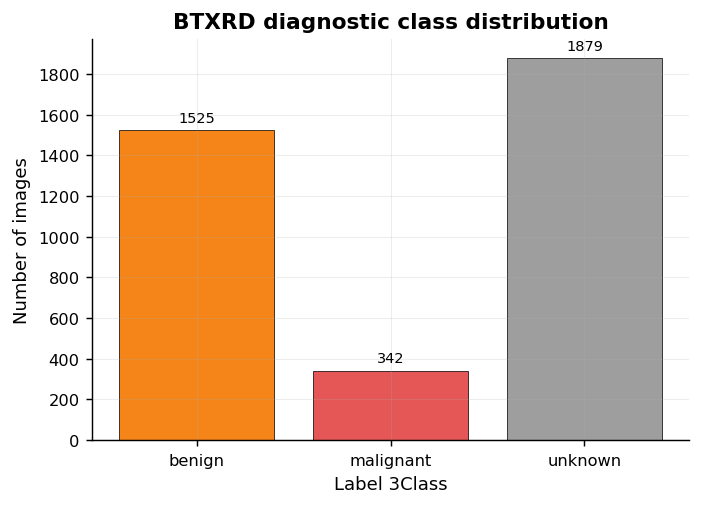

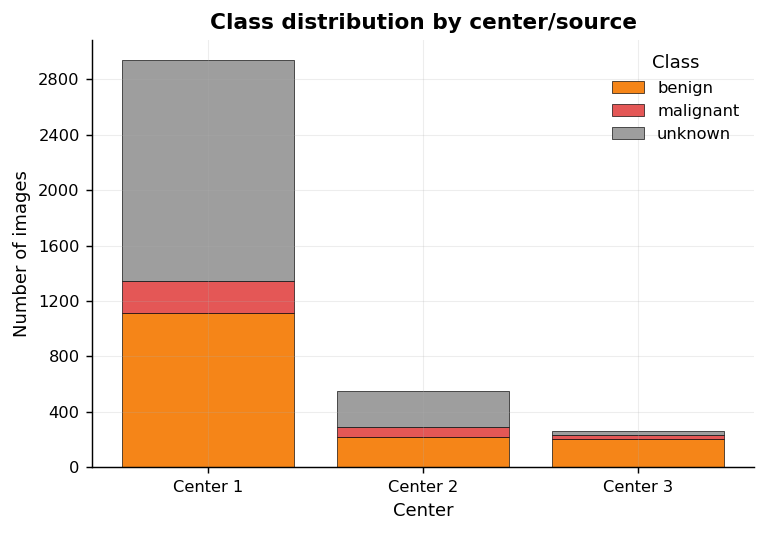

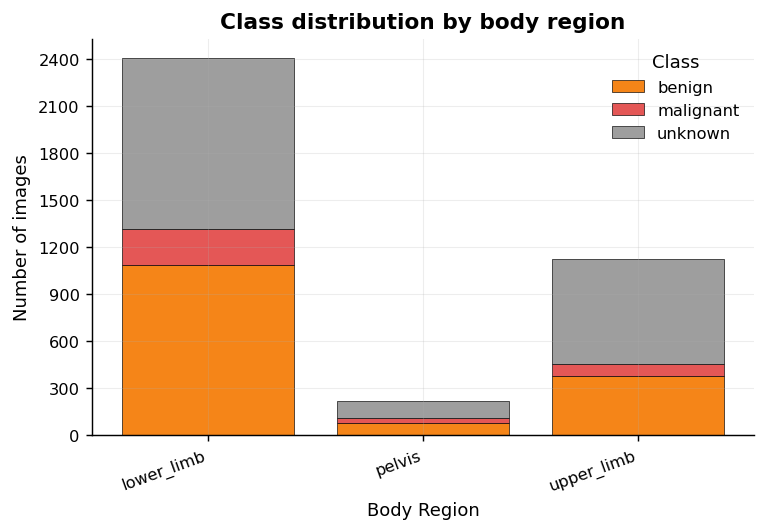

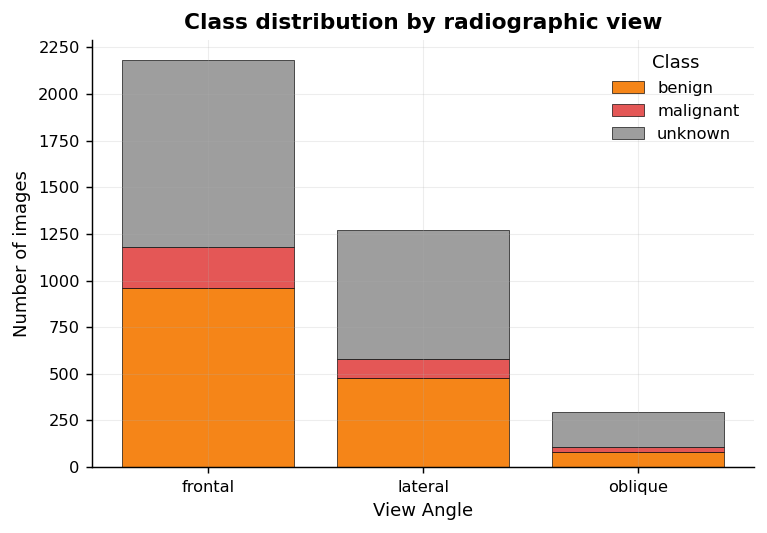

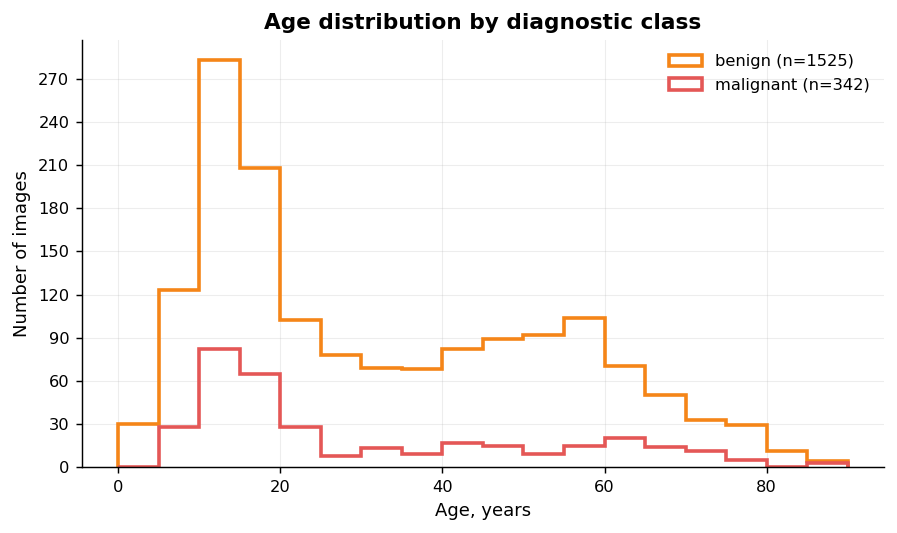

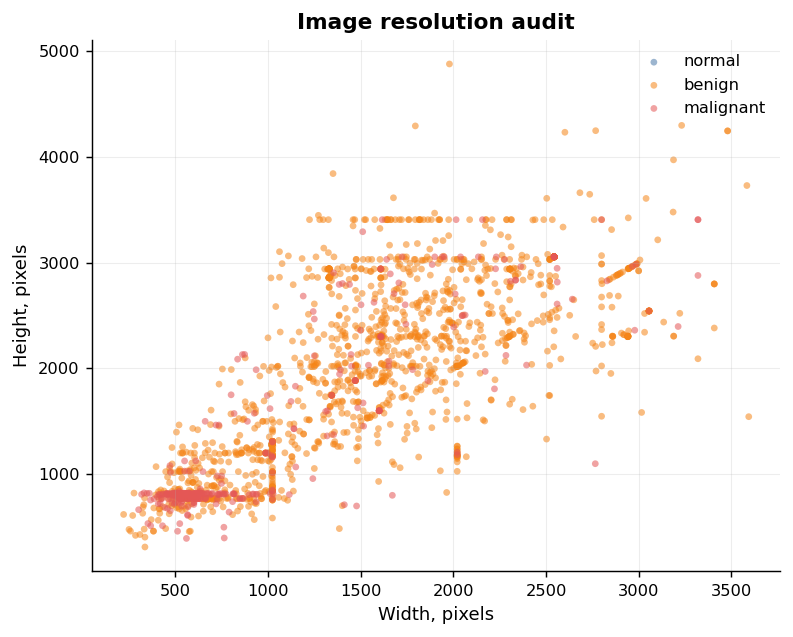

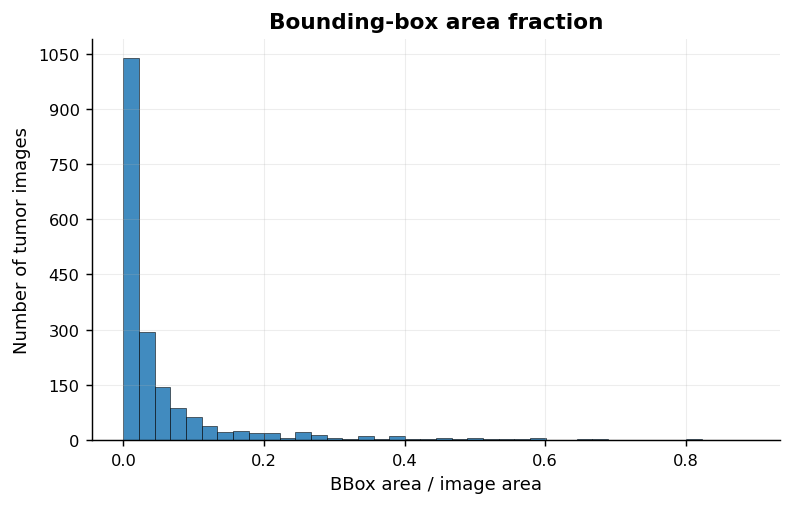

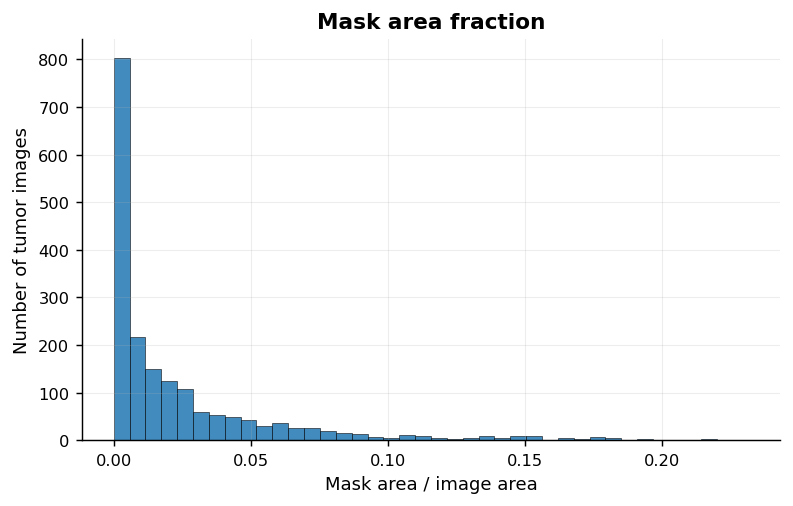

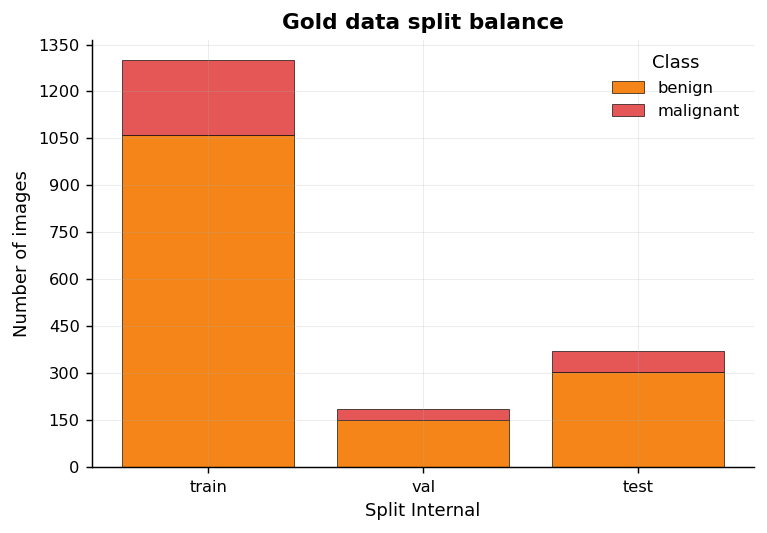

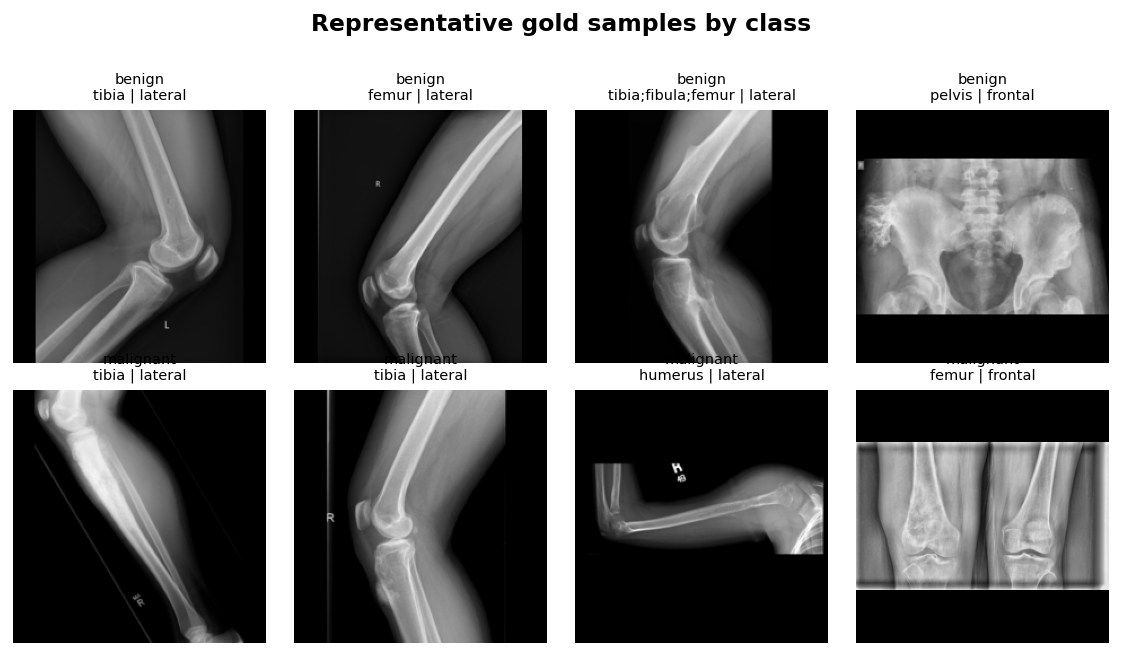

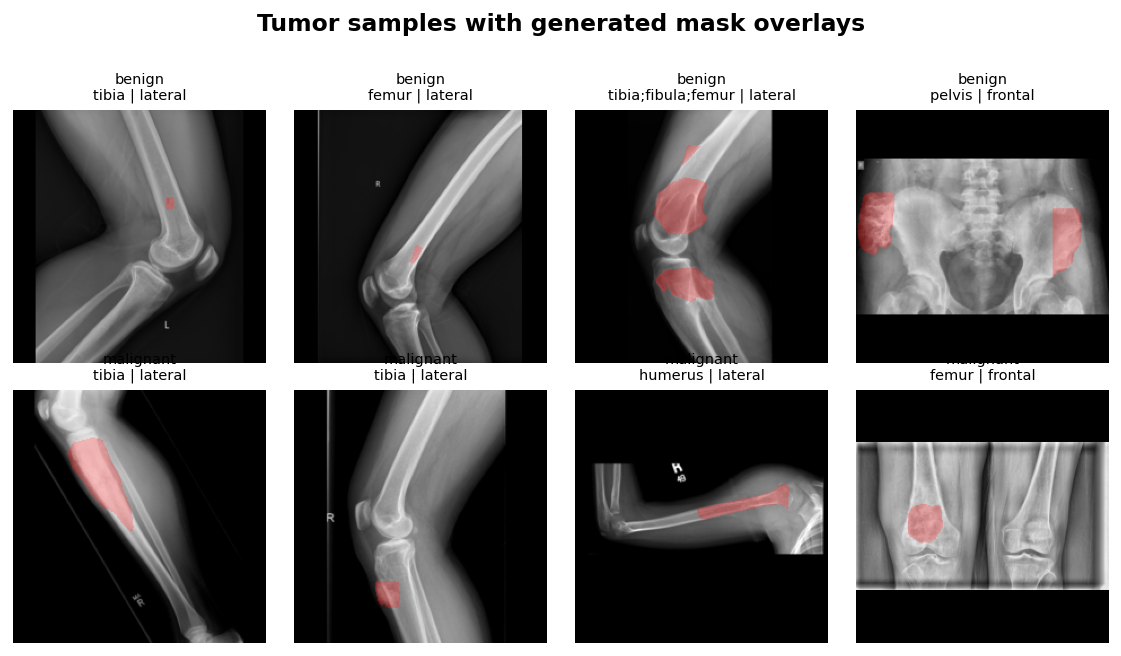

Journal figures saved to: /kaggle/working/BTXRD_Portion1/figures


In [10]:
# ============================================================
# 9. Journal-style visuals
# ============================================================

def save_current_fig(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()


def safe_value_counts(df, col, order=None):
    s = df[col].fillna("unknown").astype(str)
    vc = s.value_counts()
    if order is not None:
        idx = [x for x in order if x in vc.index] + [x for x in vc.index if x not in order]
        vc = vc.reindex(idx)
    return vc


def plot_count_bar(df, col, title, filename, order=None, xlabel=None, ylabel="Number of images", rotate=0):
    vc = safe_value_counts(df, col, order=order)
    fig, ax = plt.subplots(figsize=(max(5.5, 0.55 * len(vc)), 4.0))
    colors = [CLASS_COLORS.get(str(k), "#6B7280") for k in vc.index]
    bars = ax.bar(vc.index.astype(str), vc.values, color=colors, edgecolor="black", linewidth=0.4)
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.set_title(title, weight="bold")
    ax.set_xlabel(xlabel if xlabel else col.replace("_", " ").title())
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis="x", rotation=rotate)
    save_current_fig(FIG_DIR / filename)


def plot_stacked(df, index_col, class_col, title, filename, index_order=None, rotate=0):
    temp = df.copy()
    temp[index_col] = temp[index_col].fillna("unknown").astype(str)
    temp[class_col] = temp[class_col].fillna("unknown").astype(str)
    table = pd.crosstab(temp[index_col], temp[class_col])
    ordered_cols = [c for c in LABEL_ORDER if c in table.columns] + [c for c in table.columns if c not in LABEL_ORDER]
    table = table[ordered_cols]
    if index_order is not None:
        idx = [x for x in index_order if x in table.index] + [x for x in table.index if x not in index_order]
        table = table.reindex(idx)
    fig, ax = plt.subplots(figsize=(max(6.0, 0.65 * len(table)), 4.2))
    bottom = np.zeros(len(table))
    x = np.arange(len(table))
    for c in table.columns:
        vals = table[c].values
        ax.bar(x, vals, bottom=bottom, label=c, color=CLASS_COLORS.get(str(c), "#6B7280"), edgecolor="black", linewidth=0.35)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(table.index.astype(str), rotation=rotate, ha="right" if rotate else "center")
    ax.set_title(title, weight="bold")
    ax.set_ylabel("Number of images")
    ax.set_xlabel(index_col.replace("_", " ").title())
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(frameon=False, title="Class")
    save_current_fig(FIG_DIR / filename)
    return table


def plot_age_distribution(df, filename="fig_age_distribution_by_class.png"):
    fig, ax = plt.subplots(figsize=(7.0, 4.2))
    bins = np.arange(0, 95, 5)
    for lab in LABEL_ORDER:
        vals = pd.to_numeric(df.loc[df["label_3class"] == lab, "age"], errors="coerce").dropna()
        if len(vals) == 0:
            continue
        ax.hist(vals, bins=bins, histtype="step", linewidth=2.0, label=f"{lab} (n={len(vals)})", color=CLASS_COLORS.get(lab))
    ax.set_title("Age distribution by diagnostic class", weight="bold")
    ax.set_xlabel("Age, years")
    ax.set_ylabel("Number of images")
    ax.legend(frameon=False)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    save_current_fig(FIG_DIR / filename)


def plot_resolution_scatter(df, filename="fig_image_resolution_scatter.png"):
    fig, ax = plt.subplots(figsize=(6.2, 5.0))
    for lab in LABEL_ORDER:
        sub = df[df["label_3class"] == lab]
        ax.scatter(sub["width"], sub["height"], s=14, alpha=0.55, label=lab, color=CLASS_COLORS.get(lab), edgecolors="none")
    ax.set_title("Image resolution audit", weight="bold")
    ax.set_xlabel("Width, pixels")
    ax.set_ylabel("Height, pixels")
    ax.legend(frameon=False)
    save_current_fig(FIG_DIR / filename)


def plot_area_distribution(df, col, title, xlabel, filename):
    vals = pd.to_numeric(df[col], errors="coerce").dropna()
    vals = vals[(vals > 0) & np.isfinite(vals)]
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    ax.hist(vals, bins=40, edgecolor="black", linewidth=0.35, alpha=0.85)
    ax.set_title(title, weight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of tumor images")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    save_current_fig(FIG_DIR / filename)


def resize_with_padding_pil(img, size=256, resample=Image.Resampling.BILINEAR, fill=0):
    w, h = img.size
    scale = size / max(w, h)
    new_w, new_h = max(1, int(round(w * scale))), max(1, int(round(h * scale)))
    img_r = img.resize((new_w, new_h), resample)
    canvas = Image.new(img.mode, (size, size), fill)
    left = (size - new_w) // 2
    top = (size - new_h) // 2
    canvas.paste(img_r, (left, top))
    return canvas, (left, top, new_w, new_h)


def image_to_panel(image_path, mask_path=None, size=256):
    img = Image.open(image_path).convert("L")
    img = ImageOps.autocontrast(img)
    img_pad, placement = resize_with_padding_pil(img, size=size, fill=0)
    rgb = np.stack([np.asarray(img_pad)] * 3, axis=-1).astype(np.uint8)
    if mask_path is not None and isinstance(mask_path, str) and Path(mask_path).exists():
        mask = Image.open(mask_path).convert("L")
        w, h = img.size
        left, top, new_w, new_h = placement
        mask_r = mask.resize((new_w, new_h), Image.Resampling.NEAREST)
        mask_canvas = Image.new("L", (size, size), 0)
        mask_canvas.paste(mask_r, (left, top))
        m = np.asarray(mask_canvas) > 0
        # Red overlay.
        overlay = rgb.copy()
        overlay[m, 0] = 255
        overlay[m, 1] = (overlay[m, 1] * 0.35).astype(np.uint8)
        overlay[m, 2] = (overlay[m, 2] * 0.35).astype(np.uint8)
        rgb = (0.65 * rgb + 0.35 * overlay).astype(np.uint8)
    return rgb


def plot_sample_grid(df, filename, title, use_masks=False, n_per_class=4, size=224):
    samples = []
    for lab in LABEL_ORDER:
        sub = df[df["label_3class"] == lab]
        if len(sub) == 0:
            continue
        n = min(n_per_class, len(sub))
        samples.append(sub.sample(n=n, random_state=SEED))
    if not samples:
        return
    sample_df = pd.concat(samples, axis=0).reset_index(drop=True)
    ncols = n_per_class
    nrows = len(samples)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 2.2, nrows * 2.45))
    axes = np.asarray(axes).reshape(nrows, ncols)
    row_idx = 0
    for lab in LABEL_ORDER:
        sub = sample_df[sample_df["label_3class"] == lab].reset_index(drop=True)
        if len(sub) == 0:
            continue
        for j in range(ncols):
            ax = axes[row_idx, j]
            ax.axis("off")
            if j < len(sub):
                row = sub.iloc[j]
                mask_path = row.get("mask_path") if use_masks else None
                panel = image_to_panel(row["image_path"], mask_path=mask_path, size=size)
                ax.imshow(panel)
                subtitle = f"{lab}\n{row.get('anatomical_site', '')} | {row.get('view_angle', '')}"
                ax.set_title(subtitle, fontsize=8)
        row_idx += 1
    fig.suptitle(title, fontsize=13, weight="bold", y=1.02)
    save_current_fig(FIG_DIR / filename)


# Save count tables for journal/supplement.
for col in ["label_3class", "label_binary", "center", "body_region", "view_angle", "anatomical_site", "tumor_subtype", "quality_tier"]:
    if col in master.columns:
        safe_value_counts(master, col).to_csv(TABLE_DIR / f"count_{col}.csv", header=["count"])

# Main figures.
plot_count_bar(master, "label_3class", "BTXRD diagnostic class distribution", "fig01_class_distribution.png", order=LABEL_ORDER)
plot_stacked(master, "center", "label_3class", "Class distribution by center/source", "fig02_class_by_center.png", rotate=0)
plot_stacked(master, "body_region", "label_3class", "Class distribution by body region", "fig03_class_by_body_region.png", rotate=20)
plot_stacked(master, "view_angle", "label_3class", "Class distribution by radiographic view", "fig04_class_by_view_angle.png", rotate=0)
plot_age_distribution(master, "fig05_age_distribution_by_class.png")
plot_resolution_scatter(master, "fig06_image_resolution_scatter.png")
plot_area_distribution(master[master["annotation_expected"]], "bbox_area_frac", "Bounding-box area fraction", "BBox area / image area", "fig07_bbox_area_fraction.png")
plot_area_distribution(master[master["annotation_expected"]], "mask_area_frac", "Mask area fraction", "Mask area / image area", "fig08_mask_area_fraction.png")
plot_stacked(gold_split_df, "split_internal", "label_3class", "Gold data split balance", "fig09_gold_split_class_balance.png", index_order=["train", "val", "test"])
plot_sample_grid(gold_df, "fig10_sample_grid_by_class.png", "Representative gold samples by class", use_masks=False, n_per_class=4, size=224)
plot_sample_grid(gold_df[gold_df["label_3class"].isin(["benign", "malignant"])], "fig11_tumor_mask_overlay_grid.png", "Tumor samples with generated mask overlays", use_masks=True, n_per_class=4, size=224)

print("Journal figures saved to:", FIG_DIR)

## 10. Final audit report and compressed output

This last cell writes a concise report and compresses all generated files into a ZIP. On Kaggle, the ZIP will appear in `/kaggle/working` and can be downloaded from the right sidebar.

In [11]:
# ============================================================
# 10. Final report and ZIP
# ============================================================

def class_counts_text(df, title):
    vc = df["label_3class"].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int)
    return f"{title}: " + ", ".join([f"{k}={v}" for k, v in vc.items()])

report = f'''
# BTXRD Portion-1 Audit Report

## Dataset location

- Selected root: `{BTXRD_ROOT}`
- Images directory: `{IMAGES_DIR}`
- Annotations directory: `{ANNOTATIONS_DIR}`
- Metadata file: `{DATA_FILE}`

## Raw counts

- Metadata rows: **{len(raw_df):,}**
- Image files found: **{len(image_paths):,}**
- Annotation JSON files found: **{len(ann_paths):,}**
- Readable images matched to metadata: **{int(master['image_readable'].sum()):,}**

## Data quality

- Exact duplicate rows excluded from gold: **{int(master['is_exact_duplicate'].sum()):,}**
- Image-core valid rows: **{int(master['q_image_core'].sum()):,}**
- Tumor rows expected to have annotation: **{int(master['annotation_expected'].sum()):,}**
- Tumor rows with valid masks: **{int(master['has_valid_mask'].sum()):,}**
- Tumor rows with valid boxes: **{int(master['has_valid_bbox'].sum()):,}**

## Recommended tables

- Gold multi-task table: `{gold_path}`
- Classification-all-valid table: `{cls_path}`
- Full audited master table: `{master_path}`

## Class distribution

- {class_counts_text(master, 'All audited metadata')}
- {class_counts_text(gold_df, 'Gold multitask')}
- {class_counts_text(cls_df, 'Classification all valid')}

## Split outputs

- Gold split folder: `{gold_split_dir}`
- Classification split folder: `{cls_split_dir}`
- Center-held-out index: `{SPLIT_DIR / 'gold_multitask_center_holdout_index.csv'}`

## Recommended next step

Use `btxrd_master_gold_multitask.csv` and the `gold_multitask/train-val-test` split files for Portion 2 baseline training.
For final BTX-TrustNet, use the gold table because it preserves clean normal samples and only tumor samples with valid lesion masks and boxes.
'''.strip()

report_path = REPORT_DIR / "BTXRD_Portion1_Audit_Report.md"
report_path.write_text(report, encoding="utf-8")

display(Markdown(report))

# Compress output folder.
zip_base = OUT_DIR.parent / "BTXRD_Portion1_outputs"
zip_path = shutil.make_archive(str(zip_base), "zip", OUT_DIR)

print("\nFinal files:")
print("- Audit report:", report_path)
print("- ZIP archive:", zip_path)
print("- Output directory:", OUT_DIR)

# BTXRD Portion-1 Audit Report

## Dataset location

- Selected root: `/kaggle/input/datasets/koushikrudra/btxrd-dataset/BTXRD`
- Images directory: `/kaggle/input/datasets/koushikrudra/btxrd-dataset/BTXRD/images`
- Annotations directory: `/kaggle/input/datasets/koushikrudra/btxrd-dataset/BTXRD/Annotations`
- Metadata file: `/kaggle/input/datasets/koushikrudra/btxrd-dataset/BTXRD/dataset.xlsx`

## Raw counts

- Metadata rows: **3,746**
- Image files found: **3,746**
- Annotation JSON files found: **1,867**
- Readable images matched to metadata: **3,746**

## Data quality

- Exact duplicate rows excluded from gold: **21**
- Image-core valid rows: **1,858**
- Tumor rows expected to have annotation: **1,867**
- Tumor rows with valid masks: **1,867**
- Tumor rows with valid boxes: **1,867**

## Recommended tables

- Gold multi-task table: `/kaggle/working/BTXRD_Portion1/tables/btxrd_master_gold_multitask.csv`
- Classification-all-valid table: `/kaggle/working/BTXRD_Portion1/tables/btxrd_master_classification_all_valid.csv`
- Full audited master table: `/kaggle/working/BTXRD_Portion1/tables/btxrd_master_all_audited.csv`

## Class distribution

- All audited metadata: normal=0, benign=1525, malignant=342
- Gold multitask: normal=0, benign=1517, malignant=341
- Classification all valid: normal=0, benign=1517, malignant=341

## Split outputs

- Gold split folder: `/kaggle/working/BTXRD_Portion1/splits/gold_multitask`
- Classification split folder: `/kaggle/working/BTXRD_Portion1/splits/classification_all_valid`
- Center-held-out index: `/kaggle/working/BTXRD_Portion1/splits/gold_multitask_center_holdout_index.csv`

## Recommended next step

Use `btxrd_master_gold_multitask.csv` and the `gold_multitask/train-val-test` split files for Portion 2 baseline training.
For final BTX-TrustNet, use the gold table because it preserves clean normal samples and only tumor samples with valid lesion masks and boxes.


Final files:
- Audit report: /kaggle/working/BTXRD_Portion1/reports/BTXRD_Portion1_Audit_Report.md
- ZIP archive: /kaggle/working/BTXRD_Portion1_outputs.zip
- Output directory: /kaggle/working/BTXRD_Portion1


# Portion 1 complete

For Portion 2, start from these files:

```text
BTXRD_Portion1/tables/btxrd_master_gold_multitask.csv
BTXRD_Portion1/splits/gold_multitask/gold_multitask_train.csv
BTXRD_Portion1/splits/gold_multitask/gold_multitask_val.csv
BTXRD_Portion1/splits/gold_multitask/gold_multitask_test.csv
BTXRD_Portion1/masks_png/
BTXRD_Portion1/coco/
BTXRD_Portion1/yolo_bbox_gold/data.yaml
```

This is the clean foundation for the high-accuracy architecture stage.